# Library Imports

In [2]:

import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from routingpy import OSRM
from routingpy.exceptions import RouterApiError
from itertools import product
from math import sqrt

# 1. calculate distance matrix in Euclidean space

In [ ]:
# %%
# Load settlements data
excel_path = r"C:\Users\pietg\OneDrive - University of Glasgow\PhD Research\Phd_Data\PopulationGrid_TR_BG\Scripts\bg_2021_census\bg_census_merged_data_pivot.xlsx"
sheet_name = 'data_bg_updated2'
settlements_df = pd.read_excel(excel_path, sheet_name=sheet_name)


# Ensure required columns are present and rename for clarity
settlements_df['ekatte_id'] = settlements_df['ekatte_id'].astype(str)
settlements_df.rename(columns={'x': 'longitude', 'y': 'latitude'}, inplace=True)
coordinates = settlements_df[['longitude', 'latitude']].values.tolist()
settlement_ids = settlements_df['ekatte_id'].tolist()

In [ ]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Assume settlements_df contains the settlement data with 'longitude' and 'latitude' columns
# If you're using updated_data_bg from the script, ensure it contains the same coordinate columns.
# Here we use settlements_df; adjust as needed.

# Extract coordinates as a NumPy array (order: [longitude, latitude])
coords = settlements_df[['longitude', 'latitude']].to_numpy()

# If coordinates are in degrees, convert them approximately to kilometers.
# One degree of latitude ~111.32 km and one degree of longitude ~111.32*cos(latitude) km.
mean_lat = np.mean(coords[:, 1])
# Scale factors for longitude and latitude
scale_factor_lon = 111.32 * np.cos(np.deg2rad(mean_lat))
scale_factor_lat = 111.32

# Create scaled coordinates (in kilometers)
scaled_coords = np.empty_like(coords, dtype=np.float64)
scaled_coords[:, 0] = coords[:, 0] * scale_factor_lon
scaled_coords[:, 1] = coords[:, 1] * scale_factor_lat

# Compute the Euclidean distance matrix (in kilometers)
euclidean_distance_matrix = squareform(pdist(scaled_coords, metric='euclidean'))

# Save the Euclidean distance matrix and settlement IDs as a compressed NPZ file
np.savez_compressed("euclidean_distance_matrix.npz", distance_matrix=euclidean_distance_matrix, settlement_ids=settlements_df['ekatte_id'].to_numpy())
print("Euclidean distance matrix saved as 'euclidean_distance_matrix.npz'")

# 2. Calculate BG OSRM Distance Matrix

In [3]:
# %%
# Load settlements data
excel_path = r"C:\Users\pietg\OneDrive - University of Glasgow\PhD Research\Phd_Data\PopulationGrid_TR_BG\Scripts\bg_2021_census\bg_census_merged_data_pivot.xlsx"
sheet_name = 'data_bg_updated2'
settlements_df = pd.read_excel(excel_path, sheet_name=sheet_name)


# Ensure required columns are present and rename for clarity
settlements_df['ekatte_id'] = settlements_df['ekatte_id'].astype(str)
settlements_df.rename(columns={'x': 'longitude', 'y': 'latitude'}, inplace=True)
coordinates = settlements_df[['longitude', 'latitude']].values.tolist()
settlement_ids = settlements_df['ekatte_id'].tolist()

In [ ]:
# Initialize OSRM client (ensure your OSRM server is running at the specified base_url using Docker container)
client = OSRM(base_url='http://localhost:5001')

In [ ]:
# Compute the distance matrix with batch processing
distance_matrix = np.full((len(coordinates), len(coordinates)), np.inf, dtype=np.float32)
batch_size = 200  # Adjust based on your OSRM server capacity

for i in range(0, len(coordinates), batch_size):
    for j in range(0, len(coordinates), batch_size):
        coords_i = coordinates[i:i+batch_size]
        coords_j = coordinates[j:j+batch_size]
        all_coords = coords_i + coords_j
        sources = list(range(len(coords_i)))
        destinations = list(range(len(coords_i), len(all_coords)))
        try:
            matrix_result = client.matrix(
                all_coords,
                'driving',  # Profile as a positional argument
                sources=sources,
                destinations=destinations,
                annotations=['distance']
            )
            distances = np.array(matrix_result.distances)
            distance_matrix[i:i+len(coords_i), j:j+len(coords_j)] = distances
            print(f"Processed batches {i}-{i+len(coords_i)} and {j}-{j+len(coords_j)}")
        except RouterApiError as e:
            print(f"An error occurred for batch ({i}-{i+len(coords_i)}, {j}-{j+len(coords_j)}): {e}")
        except Exception as e:
            print(f"An unexpected error occurred: {e}")

In [ ]:
# Save the distance matrix
np.savez_compressed('distance_matrix_bg_3.npz', distance_matrix=distance_matrix, settlement_ids=settlement_ids)

# 3 Evaluate the Eucidean distance matrix vs OSRM distance matrix

In [6]:
import numpy as np

# Load the OSRM NPZ file (adjust the file name/path as needed)
osrm_data = np.load('calculated_distance_matrices/distance_matrix_bg_3.npz', allow_pickle=True)
osrm_distance_matrix = osrm_data['distance_matrix'] /1000  # distances in km
osrm_settlement_ids = np.array(osrm_data['settlement_ids'], dtype=str)

# Define the two ekatte_ids to compare (as strings)
id_origin = '68134'
id_destination = '39493'

# Find the indices for the given ekatte_ids
try:
    idx_origin = np.where(osrm_settlement_ids == id_origin)[0][0]
    idx_destination = np.where(osrm_settlement_ids == id_destination)[0][0]
except IndexError:
    raise ValueError("One or both of the provided ekatte_ids were not found in the OSRM dataset.")

# Retrieve the distance between these two settlements (origin->destination)
distance_km = osrm_distance_matrix[idx_origin, idx_destination]

print(f"OSRM distance between ekatte_id {id_origin} and {id_destination}: {distance_km:.2f} km")

OSRM distance between ekatte_id 68134 and 39493: 593.81 km


Settlement IDs match after sorting. Reordering matrices accordingly.


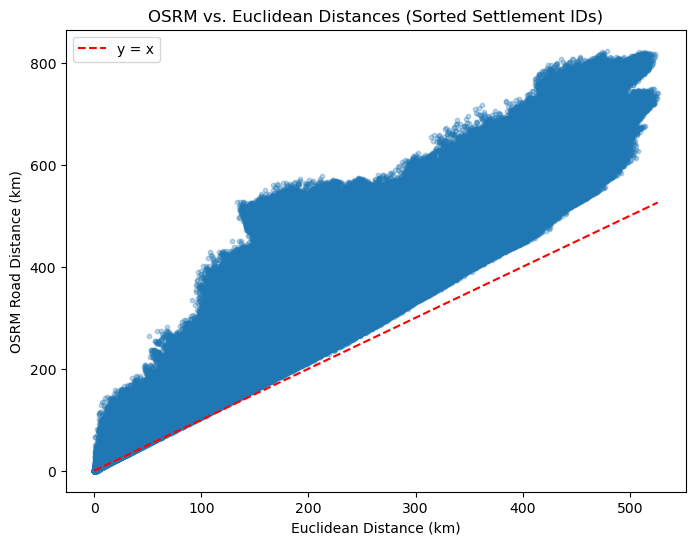

Correlation coefficient between OSRM and Euclidean distances: 0.9554722902542329


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Load the OSRM-based distance matrix (with allow_pickle=True to load string IDs)
osrm_data = np.load('calculated_distance_matrices/distance_matrix_bg_3.npz', allow_pickle=True)
osrm_distance_matrix = osrm_data['distance_matrix'] / 1000.0  # distances in km
osrm_settlement_ids = np.array(osrm_data['settlement_ids'])

# Load the Euclidean distance matrix
euclidean_data = np.load('calculated_distance_matrices/euclidean_distance_matrix.npz', allow_pickle=True)
euclidean_distance_matrix = euclidean_data['distance_matrix']  # distances in km
euclidean_settlement_ids = np.array(euclidean_data['settlement_ids'])

# Sort settlement IDs in both arrays and reorder the matrices accordingly.
sort_idx_osrm = np.argsort(osrm_settlement_ids)
sort_idx_euclidean = np.argsort(euclidean_settlement_ids)

osrm_ids_sorted = osrm_settlement_ids[sort_idx_osrm]
euclidean_ids_sorted = euclidean_settlement_ids[sort_idx_euclidean]

if np.array_equal(osrm_ids_sorted, euclidean_ids_sorted):
    print("Settlement IDs match after sorting. Reordering matrices accordingly.")
    osrm_distance_matrix_sorted = osrm_distance_matrix[np.ix_(sort_idx_osrm, sort_idx_osrm)]
    euclidean_distance_matrix_sorted = euclidean_distance_matrix[np.ix_(sort_idx_euclidean, sort_idx_euclidean)]
else:
    print("Even after sorting, the settlement IDs do not match. Please verify your input data.")
    # Optionally, you could exit here if the IDs do not match.

# Extract only the unique pairs (upper triangular part of the matrix, excluding the diagonal)
n = osrm_distance_matrix_sorted.shape[0]
triu_indices = np.triu_indices(n, k=1)
osrm_vals = osrm_distance_matrix_sorted[triu_indices]
euclidean_vals = euclidean_distance_matrix_sorted[triu_indices]

# Scatter plot: OSRM vs. Euclidean distances
plt.figure(figsize=(8, 6))
plt.scatter(euclidean_vals, osrm_vals, alpha=0.3, s=10)
plt.xlabel("Euclidean Distance (km)")
plt.ylabel("OSRM Road Distance (km)")
plt.title("OSRM vs. Euclidean Distances (Sorted Settlement IDs)")
# Plot the y=x line for reference
min_val, max_val = euclidean_vals.min(), euclidean_vals.max()
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="y = x")
plt.legend()
plt.show()

# Calculate and print the correlation coefficient
corr_coef = np.corrcoef(euclidean_vals, osrm_vals)[0, 1]
print("Correlation coefficient between OSRM and Euclidean distances:", corr_coef)

# # Histogram of relative differences: (OSRM - Euclidean) / Euclidean
# relative_diff = (osrm_vals - euclidean_vals) / euclidean_vals
# plt.figure(figsize=(8, 6))
# plt.hist(relative_diff, bins=50, color='skyblue', edgecolor='black')
# plt.xlabel("Relative Difference (OSRM - Euclidean) / Euclidean")
# plt.ylabel("Frequency")
# plt.title("Histogram of Relative Differences")
# plt.show()
